In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 

<class 'pandas.DataFrame'>
RangeIndex: 1192 entries, 0 to 1191
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   NamaFile     1192 non-null   str  
 1   BanyakOrang  1192 non-null   int64
 2   Kamera       1192 non-null   int64
 3   Label        1192 non-null   str  
dtypes: int64(2), str(2)
memory usage: 37.4 KB


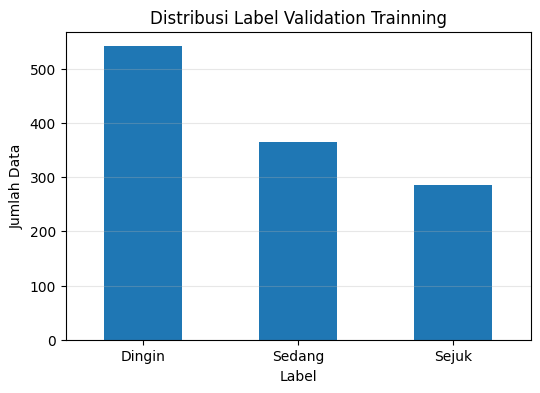

In [ ]:
df_train = pd.read_csv("Informasi Dataset - TRAINING.csv")
df_train.info()

plt.figure(figsize=(6, 4))
df_train['Label'].value_counts().plot(kind='bar')

plt.title('Distribusi Label Validation Trainning')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   NamaFile     158 non-null    str  
 1   BanyakOrang  158 non-null    int64
 2   Kamera       158 non-null    int64
 3   Label        158 non-null    str  
dtypes: int64(2), str(2)
memory usage: 5.1 KB


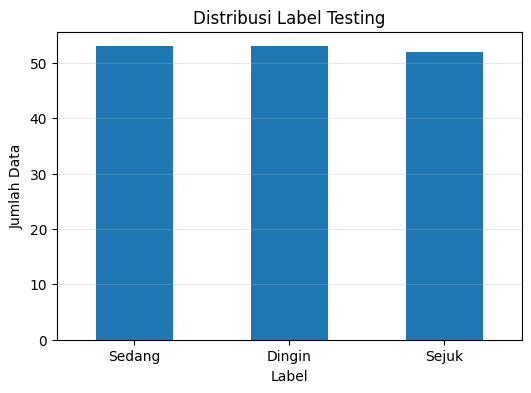

In [ ]:
df_test = pd.read_csv("Informasi Dataset - TESTING.csv")
df_test.info()

plt.figure(figsize=(6, 4))
df_test['Label'].value_counts().plot(kind='bar')

plt.title('Distribusi Label Testing')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [16]:
df_test.tail(20)

,NamaFile,BanyakOrang,Kamera,Label
138,train_0308.jpg,11,1,Dingin
139,train_0309.jpg,11,1,Dingin
140,train_0310.jpg,11,1,Dingin
141,train_0311.jpg,11,1,Dingin
142,train_0312.jpg,11,1,Dingin
143,train_0313.jpg,11,1,Dingin
144,train_0314.jpg,11,1,Dingin
145,train_0315.jpg,11,1,Dingin
146,train_0316.jpg,10,1,Dingin
147,train_0317.jpg,11,1,Dingin


<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   NamaFile     239 non-null    str  
 1   BanyakOrang  239 non-null    int64
 2   Kamera       239 non-null    int64
 3   Label        239 non-null    str  
dtypes: int64(2), str(2)
memory usage: 7.6 KB


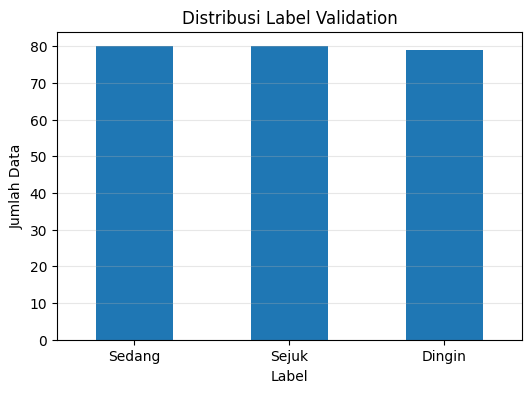

In [8]:
df_val = pd.read_csv("Informasi Dataset - VALIDATION.csv")
df_val.info()
df_val.head()

plt.figure(figsize=(6, 4))
df_val['Label'].value_counts().plot(kind='bar')

plt.title('Distribusi Label Validation')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
import shutil

SOURCE_DIR = Path("Dataset")

SOURCE_IMAGES_DIR = SOURCE_DIR / "images"
SOURCE_LABELS_DIR = SOURCE_DIR / "labels"

OUTPUT_DIR = Path("Dataset_rapih")

OUTPUT_IMAGES_DIR = OUTPUT_DIR / "images"
OUTPUT_LABELS_DIR = OUTPUT_DIR / "labels"

csv_files = {
    "train": Path("Informasi Dataset - TRAINING.csv"),
    "valid": Path("Informasi Dataset - VALIDATION.csv"),
    "test": Path("Informasi Dataset - TESTING.csv")
}

splits = ["train", "valid", "test"]

# Buat folder output
for split in splits:
    (OUTPUT_IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_LABELS_DIR / split).mkdir(parents=True, exist_ok=True)


def find_file(base_dir, filename):
    """
    Mencari file di semua split: train, valid, test.
    Contoh:
    Dataset/images/train/test_0108.jpg
    Dataset/images/valid/test_0108.jpg
    Dataset/images/test/test_0108.jpg
    """
    for split in splits:
        file_path = base_dir / split / filename
        if file_path.exists():
            return file_path
    return None


missing_images = []
missing_labels = []
copied_data = []

for target_split, csv_path in csv_files.items():
    df = pd.read_csv(csv_path)

    for idx, row in df.iterrows():
        image_name = row["NamaFile"]          
        label_name = Path(image_name).with_suffix(".txt").name 

        # Cari gambar dan label dari semua folder asal
        src_image = find_file(SOURCE_IMAGES_DIR, image_name)
        src_label = find_file(SOURCE_LABELS_DIR, label_name)

        # Tujuan copy
        dst_image = OUTPUT_IMAGES_DIR / target_split / image_name
        dst_label = OUTPUT_LABELS_DIR / target_split / label_name

        if src_image is None:
            missing_images.append((target_split, image_name))
            continue

        if src_label is None:
            missing_labels.append((target_split, label_name))
            continue

        # Copy file, bukan move, supaya data asli tetap aman
        shutil.copy2(src_image, dst_image)
        shutil.copy2(src_label, dst_label)

        copied_data.append({
            "target_split": target_split,
            "image": image_name,
            "label": label_name,
            "src_image": str(src_image),
            "dst_image": str(dst_image)
        })

print("Selesai merapihkan dataset.")
print(f"Total file berhasil dicopy: {len(copied_data)}")
print(f"Missing images: {len(missing_images)}")
print(f"Missing labels: {len(missing_labels)}")

if missing_images:
    print("Gambar yang tidak ditemukan:")
    for item in missing_images[:20]:
        print(item)

if missing_labels:
    print("Label yang tidak ditemukan:")
    for item in missing_labels[:20]:
        print(item)
        
print("\nCek jumlah data per split:")

for split, csv_path in csv_files.items():
    df = pd.read_csv(csv_path)

    image_count = len(list((OUTPUT_IMAGES_DIR / split).glob("*.jpg")))
    label_count = len(list((OUTPUT_LABELS_DIR / split).glob("*.txt")))

    print(f"\n{split}")
    print(f"Jumlah baris CSV : {len(df)}")
    print(f"Jumlah gambar    : {image_count}")
    print(f"Jumlah label     : {label_count}")
    
for split, csv_path in csv_files.items():
    df = pd.read_csv(csv_path)

    duplicate_files = df[df["NamaFile"].duplicated(keep=False)]

    print(f"\n{split}")
    print("Jumlah duplikat NamaFile:", len(duplicate_files))

    if len(duplicate_files) > 0:
        print(duplicate_files[["NamaFile", "Label"]].head(20))

Selesai merapihkan dataset.
Total file berhasil dicopy: 1589
Missing images: 0
Missing labels: 0

Cek jumlah data per split:

train
Jumlah baris CSV : 1192
Jumlah gambar    : 1192
Jumlah label     : 1192

valid
Jumlah baris CSV : 239
Jumlah gambar    : 239
Jumlah label     : 239

test
Jumlah baris CSV : 158
Jumlah gambar    : 158
Jumlah label     : 158

train
Jumlah duplikat NamaFile: 0

valid
Jumlah duplikat NamaFile: 0

test
Jumlah duplikat NamaFile: 0
